In [2]:
import pandas as pd
from bisect import bisect_right
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import numpy as np
from scipy.constants import c 

## Read the data in & match them by their time stamps

In [3]:
# prepare stage data
stage = pd.read_csv("stage.csv")
stage["Timestamp"] = pd.to_datetime(stage["Timestamp"])
print(stage)
# prepare beam profiler data
bp = pd.read_csv("beam_profiler.csv")
bp["Timestamp"] = pd.to_datetime(bp["Date"] + " " + bp["Time"])
bp["Peak cnts"] = bp["Peak cnts"].astype(float)
bp["Total cnts"] = bp["Total cnts"].astype(float)
bp = bp[["Timestamp", "Peak cnts", "Total cnts"]]
print(bp)


      Position_um                  Timestamp
0    17284.000000 2025-12-11 15:05:32.224019
1    17286.010050 2025-12-11 15:05:36.548954
2    17288.020101 2025-12-11 15:05:40.860944
3    17290.030151 2025-12-11 15:05:45.164722
4    17292.040201 2025-12-11 15:05:49.479858
..            ...                        ...
195  17675.959799 2025-12-11 15:19:34.110706
196  17677.969849 2025-12-11 15:19:38.425330
197  17679.979899 2025-12-11 15:19:42.742391
198  17681.989950 2025-12-11 15:19:47.059175
199  17684.000000 2025-12-11 15:19:51.374715

[200 rows x 2 columns]
                   Timestamp  Peak cnts  Total cnts
0    2025-12-11 15:04:39.772    2283.13  9040941.75
1    2025-12-11 15:04:40.438    2137.75  8908539.55
2    2025-12-11 15:04:41.038    2268.38  8935071.77
3    2025-12-11 15:04:41.638    2376.75  8970851.38
4    2025-12-11 15:04:42.238    2081.25  8877406.09
...                      ...        ...         ...
1447 2025-12-11 15:20:09.001     356.88  8155559.22
1448 2025-12-11 15:2

In [4]:
# sort both by time
stage = stage.sort_values("Timestamp")
bp = bp.sort_values("Timestamp")
# find the closest timestamp in the beam profiler file
bp_times = bp["Timestamp"].tolist()
bp_peaks = bp["Peak cnts"].tolist()
bp_total = bp["Total cnts"].tolist()
matched_peaks = []
matched_total = []
for ts in stage["Timestamp"]:
    idx = bisect_right(bp_times, ts)
    if idx < len(bp_times):
        matched_peaks.append(bp_peaks[idx])
        matched_total.append(bp_total[idx])
    else:
        matched_peaks.append(None)
        matched_total.append(None)
stage["Peak cnts"] = matched_peaks
stage["Total cnts"] = matched_total
# save results
stage.to_csv("matched_data", index=False)


## Plot & fit data

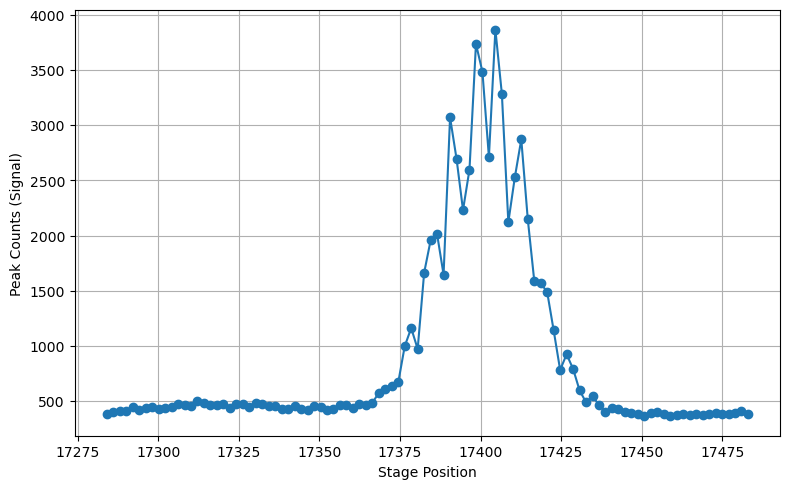

In [5]:
# plotting
plot_data = stage.dropna(subset=["Total cnts"])                                 

# keep only first half
half = len(plot_data) // 2
plot_data = plot_data.iloc[:half]

plt.figure(figsize=(8,5))
plt.plot(plot_data["Position_um"], plot_data["Peak cnts"], marker="o")        
plt.xlabel("Stage Position")
plt.ylabel("Peak Counts (Signal)")                                             
plt.grid(True)
plt.tight_layout()
plt.show()


In [6]:
# Fitting
def gaussian(x, A, x0, tau_AC, offset):
    return A * np.exp(-  (x - x0)**2 / (tau_AC**2)) + offset

x = np.array([2 *x*20/2.9979246  for x in plot_data["Position_um"].values])    # convert stage position to time delay
y = plot_data["Peak cnts"].values

# Initial guesses: amplitude, center, width, offset
p0 = [y.max(), x[np.argmax(y)], (x.max()-x.min())/5, y.min()]

params, cov = curve_fit(gaussian, x, y, p0=p0)
A, x0, tau, offset = params
errors = np.sqrt(np.diag(cov))
A_err, tau_err, x0_err, y0_err = errors

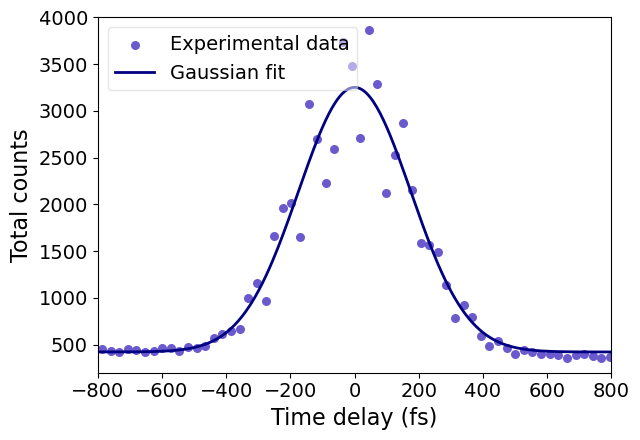

In [28]:
# Plot fit
x_fit = np.linspace(x.min(), x.max(), 500)
y_fit = gaussian(x_fit, *params)

plt.figure(figsize=(6.5,4.5))
plt.scatter((x-x0), y, label="Experimental data", s=30, color='slateblue')
plt.plot((x_fit-x0), y_fit, label="Gaussian fit", linewidth=2, color="navy")
plt.xlabel("Time delay (fs)", fontsize=16)
plt.ylabel("Total counts", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlim([-800, 800])
plt.ylim([200, 4000])
plt.legend(fontsize=14, loc='upper left', framealpha=0.5)
plt.tight_layout()
plt.savefig('03_AutocorrelationMeasurement.pdf')
plt.show()

In [8]:
print(f"A (amplitude) = {A}")
print(f"x0 (center)   = {x0}")
print(f"tau         = {tau}")
print(f"tau_err = {tau_err}")
print(f"offset        = {offset}")

A (amplitude) = 2830.6719302638467
x0 (center)   = 232177.60265636086
tau         = 247.46931918381915
tau_err = 5.122563803122933
offset        = 422.00328436243655


In [9]:
print("τ_FWHM =", tau * np.sqrt(np.log(2)/2) )    # convert to FWHM

τ_FWHM = 145.68642833605486


In [ ]:
print("Δτ_FWHM =", tau_err * np.sqrt(np.log(2)/2) ) # calculate error 

3.015678981385964
